# Customer Intelligence System using Classification, Ensemble & Clustering

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Clustering
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import silhouette_score

# Classification
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

import warnings
warnings.filterwarnings('ignore')


## 2. Load the Data & First Look

In [2]:
df = pd.read_csv("Country-data.csv")
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [3]:
df.shape

(167, 10)

In [4]:
df['country'].value_counts().sum()

167

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [6]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


### 2.1 Check for Missing Values & Duplicates

In [7]:
df.isnull().sum()

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

In [8]:
df.duplicated().sum()

0

**Observation:** The dataset has **167 rows and 10 columns** (`country` + 9 numeric socio-economic/health indicators), with **no missing values** and **no duplicate rows**, so it is clean and ready for analysis.

## 3. Exploratory Data Analysis (EDA)

### 3.1 Univariate Analysis — Distribution of Features

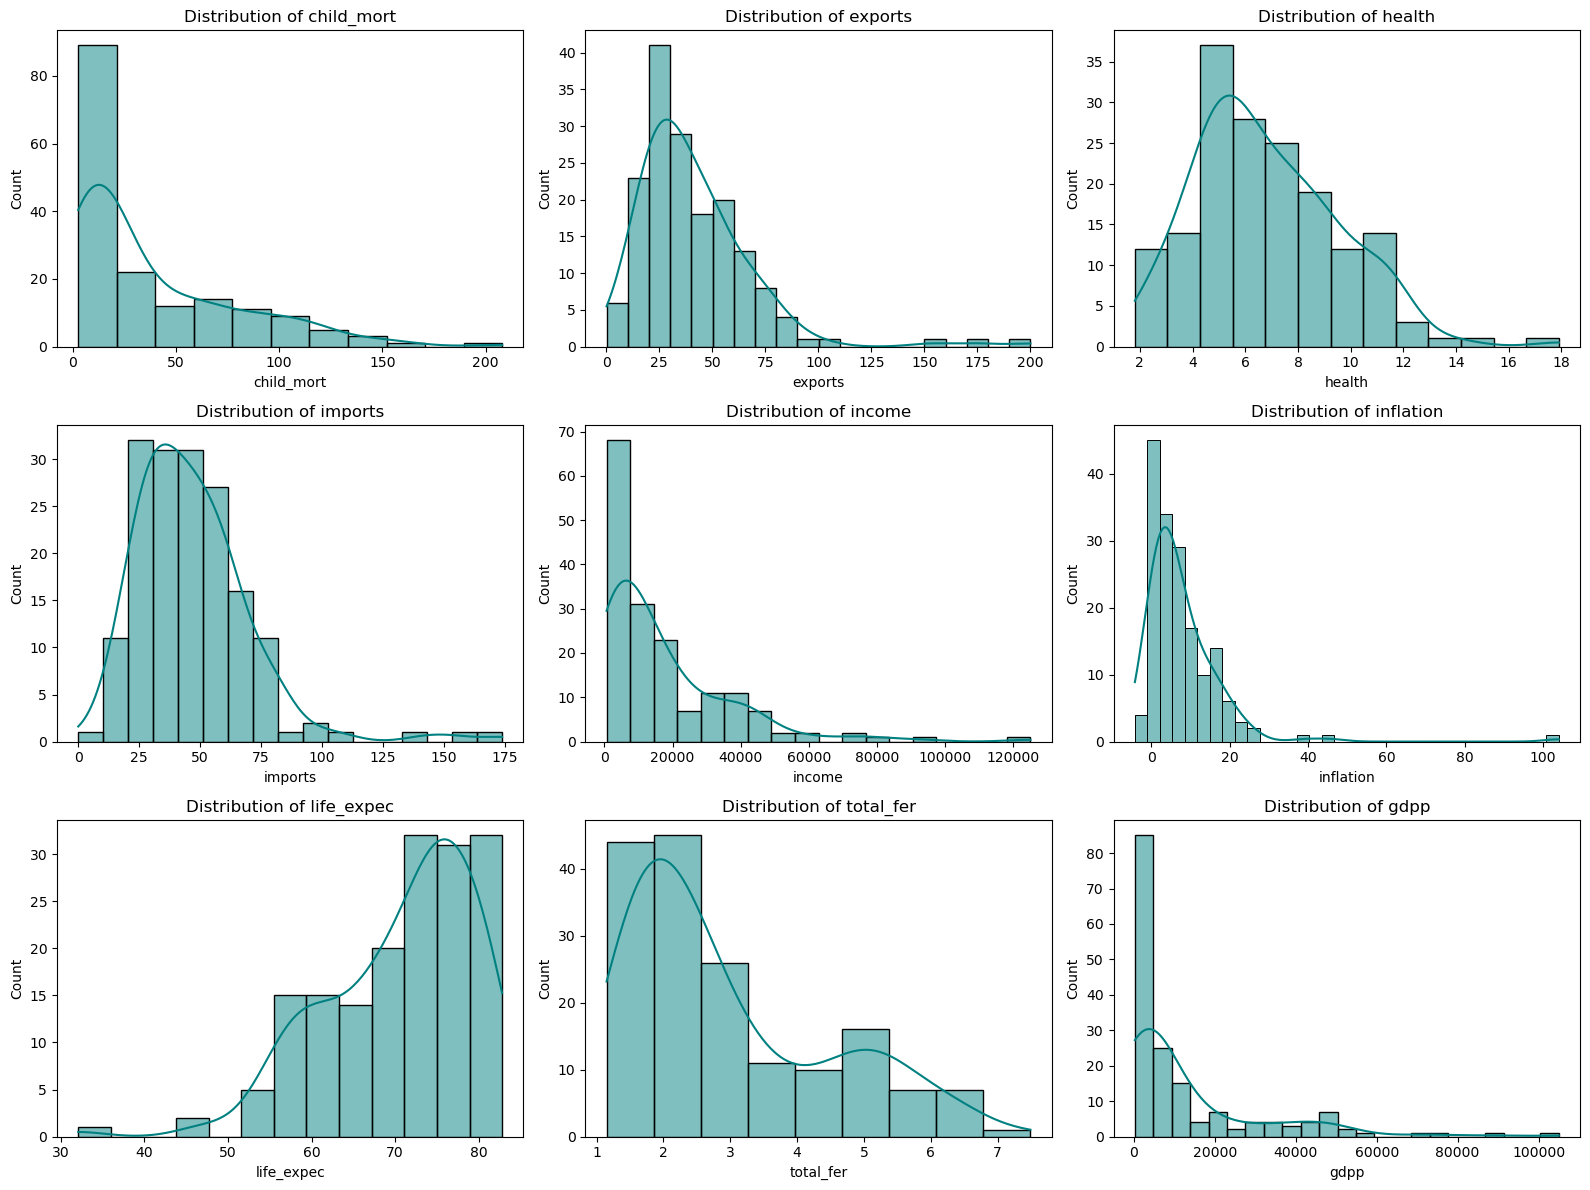

In [9]:
num_cols = df.columns[1:]

plt.figure(figsize=(16, 12))
for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df[col], kde=True, color='teal')
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

**Observation:** Most features (`child_mort`, `exports`, `income`, `inflation`, `gdpp`) are **right-skewed** — a small number of countries have very high values (e.g., very high income/GDP per capita) while most countries cluster at lower values. `life_expec` is left-skewed, while `health` and `total_fer` are closer to a normal distribution.

### 3.2 Correlation Analysis

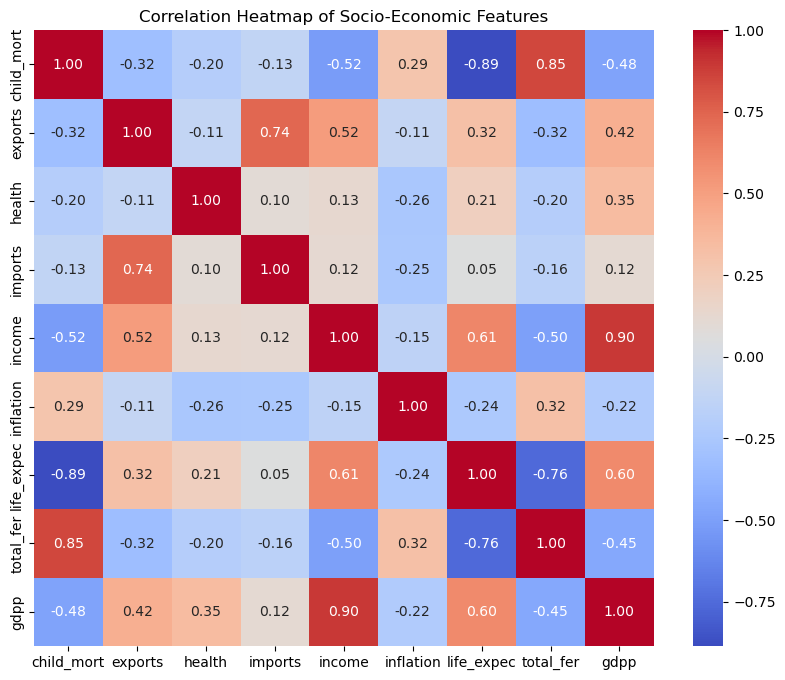

In [10]:
plt.figure(figsize=(10, 8))
corr = df.iloc[:, 1:].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Socio-Economic Features')
plt.show()

**Observation:**
- `income` and `gdpp` are **strongly positively correlated** (~0.9), both reflecting a country's wealth.
- `child_mort` and `total_fer` are **strongly positively correlated** (~0.85) — countries with higher fertility rates tend to have higher child mortality.
- `child_mort` is **strongly negatively correlated** with `life_expec` (~-0.89) — higher child mortality is associated with lower life expectancy.
- `exports` and `imports` are also positively correlated (~0.74), as expected for trade-dependent economies.

These strongly correlated groups will likely drive the cluster separations we see later.

### 3.3 Outlier Detection

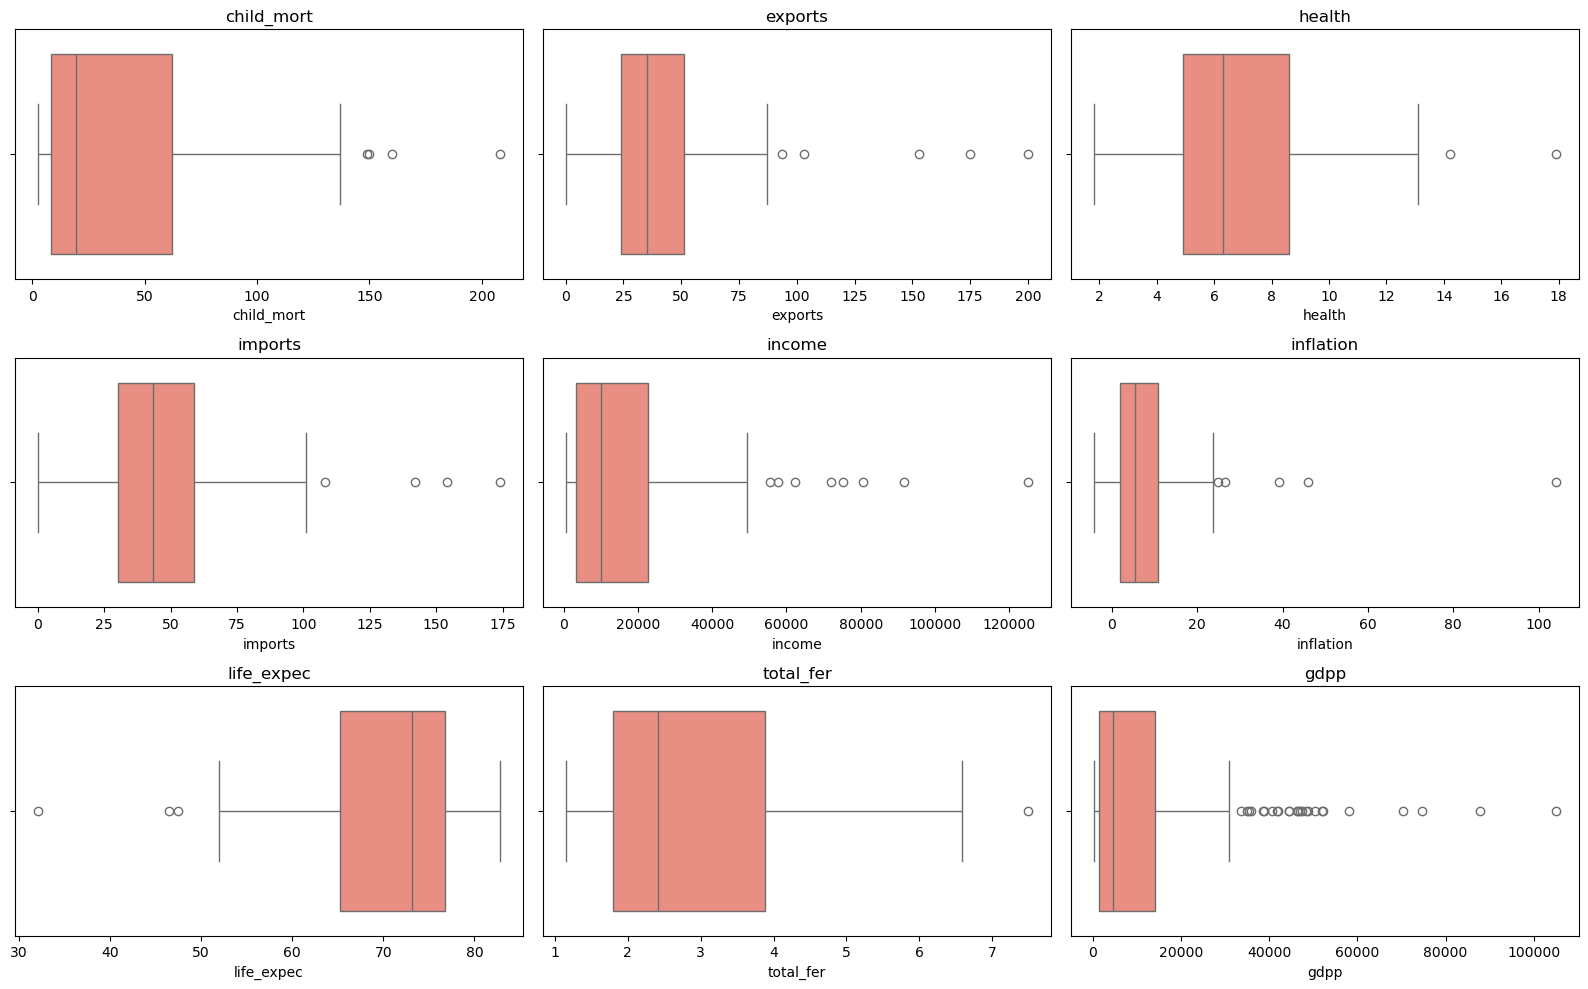

In [11]:
plt.figure(figsize=(16, 10))
for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(x=df[col], color='salmon')
    plt.title(col)
plt.tight_layout()
plt.show()

**Observation:** `income`, `gdpp`, and `child_mort` show several high-value outliers — these correspond to very wealthy nations (e.g., Qatar, Luxembourg) and very low-income/high-mortality nations (e.g., several African countries). These are **genuine, meaningful extreme values** (not data errors), so they are retained — they are exactly the kind of extreme "customers" a segmentation/intelligence system needs to identify.

## 4. Feature Scaling

Clustering algorithms (K-Means, DBSCAN, Hierarchical) and distance-based classifiers are sensitive to feature scale. Since features like `income`/`gdpp` (in thousands) and `inflation`/`total_fer` (single digits) are on very different scales, we standardize all numeric features using `StandardScaler` (zero mean, unit variance) before modelling.

In [12]:
X = df.drop(columns='country')

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
scaled_df.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.291532,-1.138280,0.279088,-0.082455,-0.808245,0.157336,-1.619092,1.902882,-0.679180
1,-0.538949,-0.479658,-0.097016,0.070837,-0.375369,-0.312347,0.647866,-0.859973,-0.485623
2,-0.272833,-0.099122,-0.966073,-0.641762,-0.220844,0.789274,0.670423,-0.038404,-0.465376
3,2.007808,0.775381,-1.448071,-0.165315,-0.585043,1.387054,-1.179234,2.128151,-0.516268
4,-0.695634,0.160668,-0.286894,0.497568,0.101732,-0.601749,0.704258,-0.541946,-0.041817


In [13]:
scaled_df.shape

(167, 9)

## 5. Clustering — Unsupervised Customer Segmentation

We now segment the 167 "customers" (countries) into meaningful groups based on their socio-economic profile, using three clustering algorithms: **K-Means**, **Hierarchical Clustering**, and **DBSCAN**.

### 5.1 K-Means Clustering

#### 5.1.1 Elbow Method — choosing the number of clusters

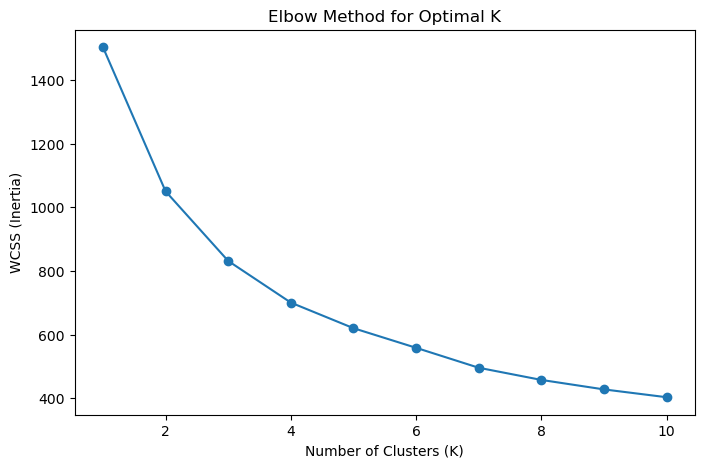

In [14]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS (Inertia)")
plt.title("Elbow Method for Optimal K")
plt.show()

#### 5.1.2 Silhouette Score — confirming the optimal K

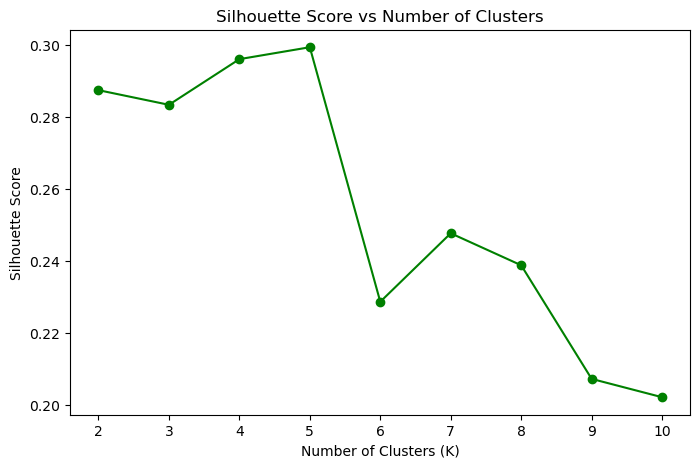

In [15]:
sil_scores = []

for i in range(2, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), sil_scores, marker='o', color='green')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs Number of Clusters")
plt.show()

**Observation:** The elbow in the WCSS curve appears around **K = 3**, and the silhouette score is also highest/relatively high at **K = 3**. We therefore proceed with **K = 3 clusters**, consistent with grouping countries into broad development tiers (e.g., *developed*, *developing*, and *under-developed/needs-aid*).

#### 5.1.3 Final K-Means Model (K = 3)

In [16]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)

df['KMeans_Cluster'].value_counts()

KMeans_Cluster
2    84
1    47
0    36
Name: count, dtype: int64

#### 5.1.4 Visualizing the Clusters (PCA Projection)

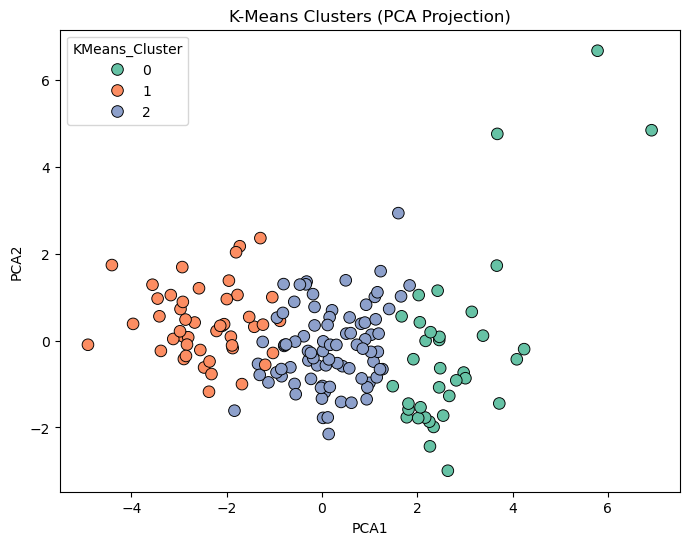

Variance explained by PCA1 & PCA2: 63.13%


In [17]:
pca = PCA(n_components=2, random_state=42)
pca_components = pca.fit_transform(X_scaled)

df['PCA1'] = pca_components[:, 0]
df['PCA2'] = pca_components[:, 1]

plt.figure(figsize=(8, 6))
sns.scatterplot(x='PCA1', y='PCA2', hue='KMeans_Cluster', data=df,
                palette='Set2', s=70, edgecolor='k')
plt.title('K-Means Clusters (PCA Projection)')
plt.show()

print(f"Variance explained by PCA1 & PCA2: {pca.explained_variance_ratio_.sum():.2%}")

#### 5.1.5 Cluster Profiling

In [18]:
cluster_profile = df.groupby('KMeans_Cluster')[num_cols].mean().round(2)
cluster_profile

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
KMeans_Cluster,,,,,,,,,
0,5.00,58.74,8.81,51.49,45672.22,2.67,80.13,1.75,42494.44
1,92.96,29.15,6.39,42.32,3942.40,12.02,59.19,5.01,1922.38
2,21.93,40.24,6.20,47.47,12305.60,7.60,72.81,2.31,6486.45


In [19]:
for c in sorted(df['KMeans_Cluster'].unique()):
    print(f"Cluster {c} sample countries:", df[df['KMeans_Cluster'] == c]['country'].sample(5, random_state=1).tolist())

Cluster 0 sample countries: ['Spain', 'United Kingdom', 'Slovenia', 'Belgium', 'Luxembourg']
Cluster 1 sample countries: ['Lao', 'Kenya', 'South Africa', 'Pakistan', 'Benin']
Cluster 2 sample countries: ['Belize', 'Seychelles', 'Peru', 'Hungary', 'Vietnam']


In [20]:
segment_map = {0: 'Developed / High-Value', 1: 'Under-developed / Needs Support', 2: 'Developing / Mid-Value'}
df['Segment'] = df['KMeans_Cluster'].map(segment_map)
df[['country', 'Segment']].sample(10, random_state=1)

,country,Segment
44,Denmark,Developed / High-Value
47,Egypt,Developing / Mid-Value
143,Suriname,Developing / Mid-Value
66,Haiti,Under-developed / Needs Support
147,Tanzania,Under-developed / Needs Support
11,Bahrain,Developed / High-Value
78,Jordan,Developing / Mid-Value
35,Colombia,Developing / Mid-Value
99,Mauritania,Under-developed / Needs Support
14,Belarus,Developing / Mid-Value


### 5.2 Hierarchical Clustering

We cross-check the K-Means segmentation with **Agglomerative (Hierarchical) Clustering** using Ward's linkage.

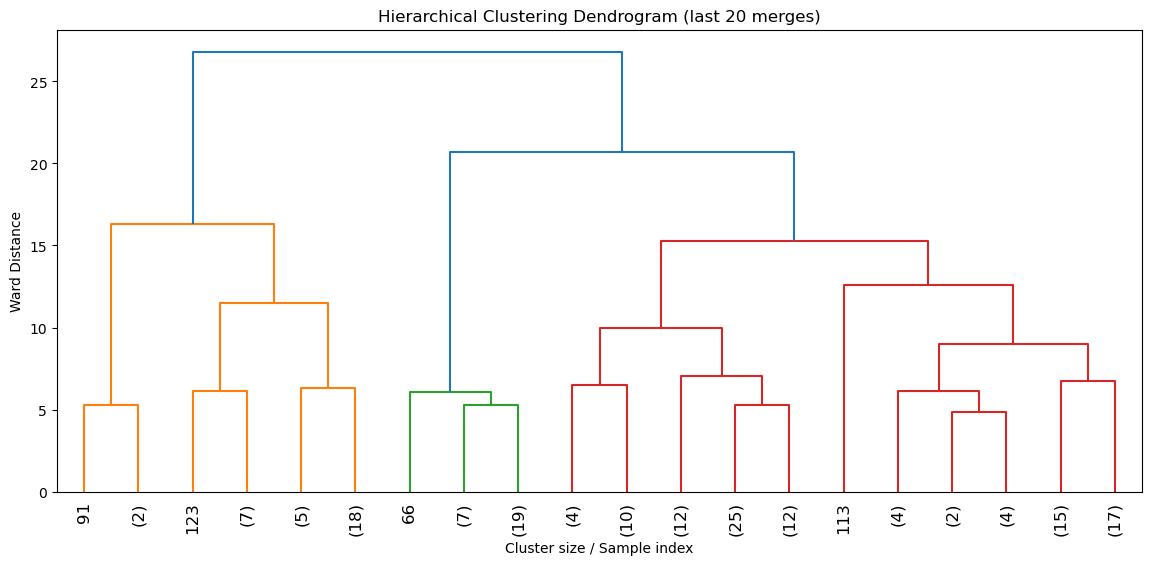

In [21]:
plt.figure(figsize=(14, 6))
linked = linkage(X_scaled, method='ward')
dendrogram(linked, truncate_mode='lastp', p=20, leaf_rotation=90)
plt.title('Hierarchical Clustering Dendrogram (last 20 merges)')
plt.xlabel('Cluster size / Sample index')
plt.ylabel('Ward Distance')
plt.show()

In [22]:
hc = AgglomerativeClustering(n_clusters=3, linkage='ward')
df['Hierarchical_Cluster'] = hc.fit_predict(X_scaled)

df['Hierarchical_Cluster'].value_counts()

Hierarchical_Cluster
1    106
0     34
2     27
Name: count, dtype: int64

In [23]:
print("Silhouette Score (K-Means):     ", round(silhouette_score(X_scaled, df['KMeans_Cluster']), 3))
print("Silhouette Score (Hierarchical):", round(silhouette_score(X_scaled, df['Hierarchical_Cluster']), 3))

Silhouette Score (K-Means):      0.283
Silhouette Score (Hierarchical): 0.246


**Observation:** The dendrogram also shows **3 well-separated high-level groups**, supporting the choice of K = 3. K-Means achieves a slightly higher silhouette score, so it remains our primary segmentation, while hierarchical clustering visually confirms the same broad grouping structure.

### 5.3 DBSCAN (Density-Based Clustering)

DBSCAN groups points that are densely packed together and marks isolated points as **noise/outliers** — useful for flagging unusual "customers" that don't fit any mainstream segment.

#### 5.3.1 Choosing `eps` via the K-Distance Graph

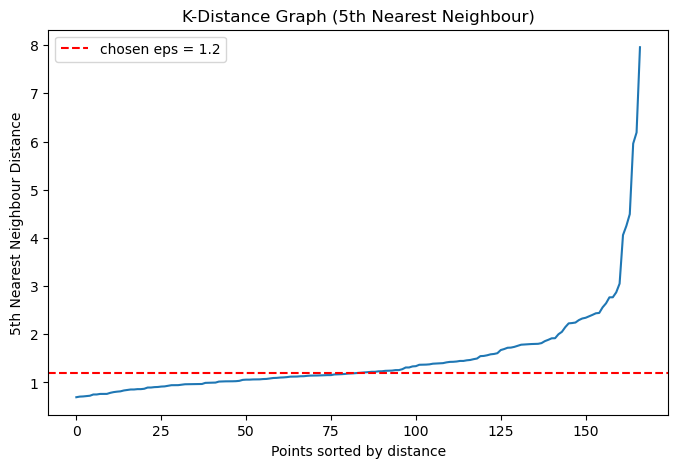

In [24]:
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled)
distances, _ = neighbors_fit.kneighbors(X_scaled)

k_distances = np.sort(distances[:, 4])

plt.figure(figsize=(8, 5))
plt.plot(k_distances)
plt.title('K-Distance Graph (5th Nearest Neighbour)')
plt.xlabel('Points sorted by distance')
plt.ylabel('5th Nearest Neighbour Distance')
plt.axhline(y=1.2, color='red', linestyle='--', label='chosen eps = 1.2')
plt.legend()
plt.show()

#### 5.3.2 Fitting DBSCAN

In [25]:
dbscan = DBSCAN(eps=1.2, min_samples=5)
df['DBSCAN_Cluster'] = dbscan.fit_predict(X_scaled)

df['DBSCAN_Cluster'].value_counts()

DBSCAN_Cluster
 1    75
-1    53
 0    21
 2    18
Name: count, dtype: int64

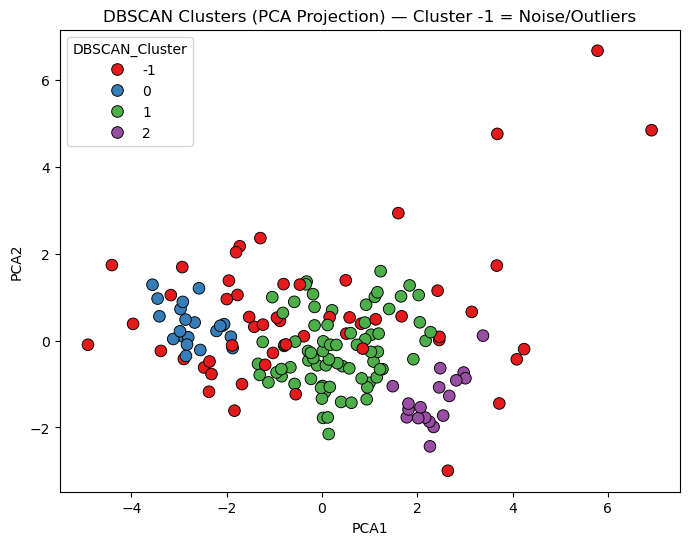

In [26]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='PCA1', y='PCA2', hue='DBSCAN_Cluster', data=df,
                palette='Set1', s=70, edgecolor='k')
plt.title('DBSCAN Clusters (PCA Projection) — Cluster -1 = Noise/Outliers')
plt.show()

In [27]:
df.groupby('DBSCAN_Cluster')[num_cols].mean().round(2)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
DBSCAN_Cluster,,,,,,,,,
-1,51.82,50.78,6.76,54.66,22391.15,12.83,67.65,3.42,16014.53
0,96.72,24.78,5.68,38.81,1830.57,7.04,58.80,5.48,772.38
1,20.51,40.16,6.37,46.64,12878.53,5.96,73.39,2.18,7457.65
2,4.17,35.63,10.17,34.49,37338.89,1.36,81.01,1.80,41150.00


**Observation:** DBSCAN finds **3 dense clusters** (broadly matching the "Developed", "Developing" and "Under-developed" groups from K-Means) plus **53 "noise" countries (-1)** with mean indicators that fall *between* the dense groups — i.e., transitional/borderline economies that don't fit neatly into one segment. This is a useful additional signal: these borderline countries may need individual review rather than a blanket segment-level strategy.


We proceed with the **K-Means segments (`KMeans_Cluster` / `Segment`)** as the ground-truth label for the classification stage, since they give a clean, balanced 3-class target that aligns with a real-world "customer tiering" use case.

## 6. Classification — Predicting the Customer Segment

Re-running a full clustering pipeline every time a *new* customer (country) arrives is expensive. Instead, we train a **classifier** on the segments discovered above, so that **new records can be instantly assigned to the correct segment** from their raw features — this is the predictive core of the "Customer Intelligence System".

### 6.1 Train-Test Split

In [28]:
X_clf = scaled_df.copy()
y_clf = df['KMeans_Cluster']

X_train, X_test, y_train, y_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)
print("\nClass distribution in train:\n", y_train.value_counts(normalize=True).round(2))

Train shape: (133, 9)
Test shape : (34, 9)

Class distribution in train:
 KMeans_Cluster
2    0.50
1    0.28
0    0.22
Name: proportion, dtype: float64


### 6.2 Helper Function for Training & Evaluation

In [29]:
def evaluate_model(model, X_train, X_test, y_train, y_test, name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    print(f"--- {name} ---")
    print(classification_report(y_test, y_pred, digits=3))

    return {'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1}, model

### 6.3 Baseline Classification Models

Before moving to ensembles, we establish baselines using **Logistic Regression** and a single **Decision Tree** .

In [30]:
results_list = []

res, _ = evaluate_model(LogisticRegression(max_iter=1000, random_state=42),
                         X_train, X_test, y_train, y_test, 'Logistic Regression')
results_list.append(res)

res, _ = evaluate_model(DecisionTreeClassifier(random_state=42),
                         X_train, X_test, y_train, y_test, 'Decision Tree')
results_list.append(res)

--- Logistic Regression ---
              precision    recall  f1-score   support

           0      1.000     1.000     1.000         7
           1      1.000     1.000     1.000        10
           2      1.000     1.000     1.000        17

    accuracy                          1.000        34
   macro avg      1.000     1.000     1.000        34
weighted avg      1.000     1.000     1.000        34

--- Decision Tree ---
              precision    recall  f1-score   support

           0      0.875     1.000     0.933         7
           1      1.000     0.900     0.947        10
           2      0.941     0.941     0.941        17

    accuracy                          0.941        34
   macro avg      0.939     0.947     0.941        34
weighted avg      0.945     0.941     0.941        34



### 6.4 Ensemble Classification Models


In [31]:
res, rf_model = evaluate_model(RandomForestClassifier(n_estimators=100, random_state=42),
                                X_train, X_test, y_train, y_test, 'Random Forest')
results_list.append(res)

res, ada_model = evaluate_model(AdaBoostClassifier(random_state=42),
                                 X_train, X_test, y_train, y_test, 'AdaBoost')
results_list.append(res)

res, gb_model = evaluate_model(GradientBoostingClassifier(random_state=42),
                                X_train, X_test, y_train, y_test, 'Gradient Boosting')
results_list.append(res)

res, xgb_model = evaluate_model(XGBClassifier(random_state=42, eval_metric='mlogloss'),
                                 X_train, X_test, y_train, y_test, 'XGBoost')
results_list.append(res)

--- Random Forest ---
              precision    recall  f1-score   support

           0      1.000     1.000     1.000         7
           1      1.000     1.000     1.000        10
           2      1.000     1.000     1.000        17

    accuracy                          1.000        34
   macro avg      1.000     1.000     1.000        34
weighted avg      1.000     1.000     1.000        34

--- AdaBoost ---
              precision    recall  f1-score   support

           0      0.000     0.000     0.000         7
           1      0.875     0.700     0.778        10
           2      0.615     0.941     0.744        17

    accuracy                          0.676        34
   macro avg      0.497     0.547     0.507        34
weighted avg      0.565     0.676     0.601        34

--- Gradient Boosting ---
              precision    recall  f1-score   support

           0      1.000     1.000     1.000         7
           1      1.000     0.900     0.947        10
          

### 6.5 Model Comparison

In [32]:
results_df = pd.DataFrame(results_list).sort_values(by='F1-Score', ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,1.000000,1.000000,1.000000,1.000000
1,Random Forest,1.000000,1.000000,1.000000,1.000000
2,Gradient Boosting,0.970588,0.972222,0.970588,0.970234
3,Decision Tree,0.941176,0.944853,0.941176,0.941383
4,XGBoost,0.941176,0.947368,0.941176,0.940905
5,AdaBoost,0.676471,0.565045,0.676471,0.600851


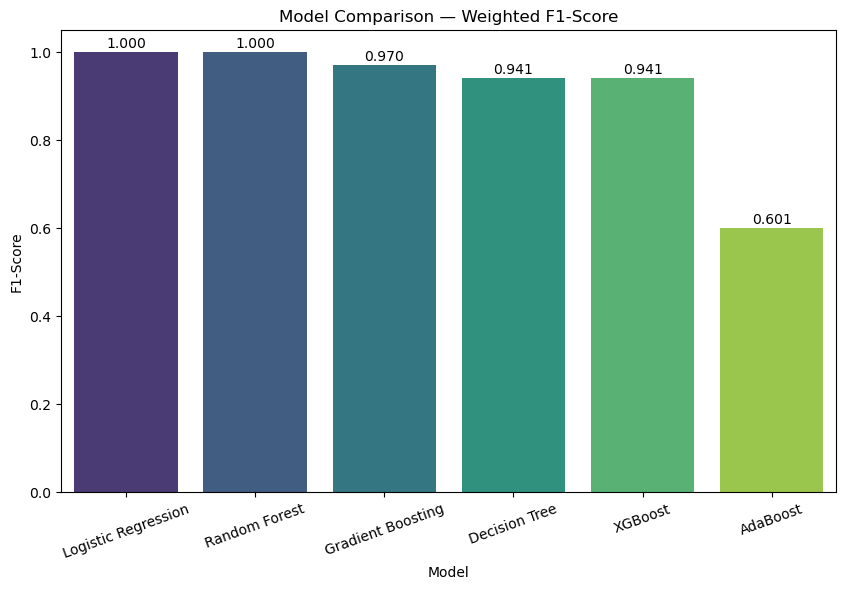

In [33]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='F1-Score', data=results_df, palette='viridis')
plt.title('Model Comparison — Weighted F1-Score')
plt.ylim(0, 1.05)
plt.xticks(rotation=20)
for i, v in enumerate(results_df['F1-Score']):
    plt.text(i, v + 0.01, f"{v:.3f}", ha='center')
plt.show()

**Observation:** **Logistic Regression** and **Random Forest** both achieve a **perfect weighted F1-score (1.00)** on the test set, while the other ensembles — **Gradient Boosting / AdaBoost (~0.97)** and **XGBoost (~0.94)** — are also very strong, all comfortably ahead of the single Decision Tree. This shows the K-Means segments are highly separable from the raw socio-economic features. We carry **Random Forest forward** as the representative ensemble model for feature-importance analysis and tuning, since ensembles like Random Forest/XGBoost are generally far more robust than a single linear model on larger, noisier, real-world "customer" data.

### 6.6 Confusion Matrix — Best Model (Random Forest)

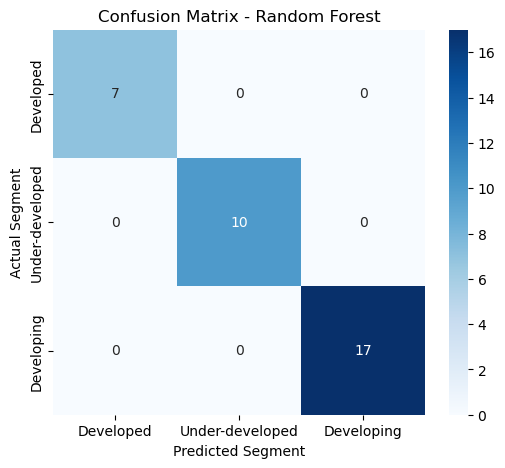

In [34]:
y_pred_rf = rf_model.predict(X_test)

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Developed', 'Under-developed', 'Developing'],
            yticklabels=['Developed', 'Under-developed', 'Developing'])
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted Segment')
plt.ylabel('Actual Segment')
plt.show()

### 6.7 Feature Importance

Understanding *which features drive segment membership* is itself a key piece of "customer intelligence" — it tells the business which indicators to monitor most closely.

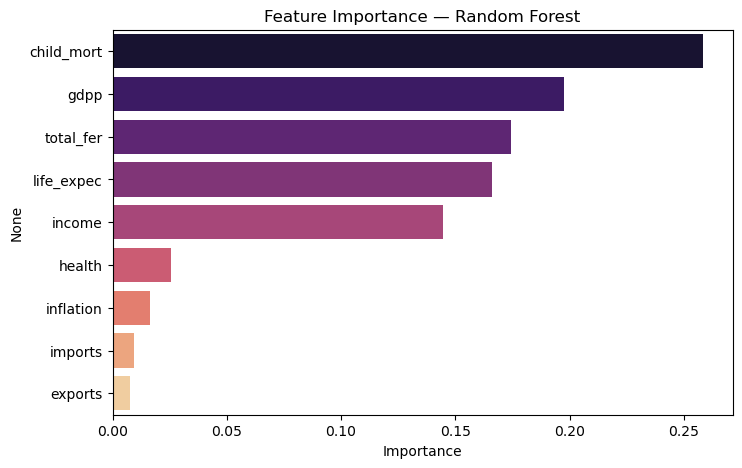

In [35]:
rf_importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=rf_importances.values, y=rf_importances.index, palette='magma')
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance')
plt.show()

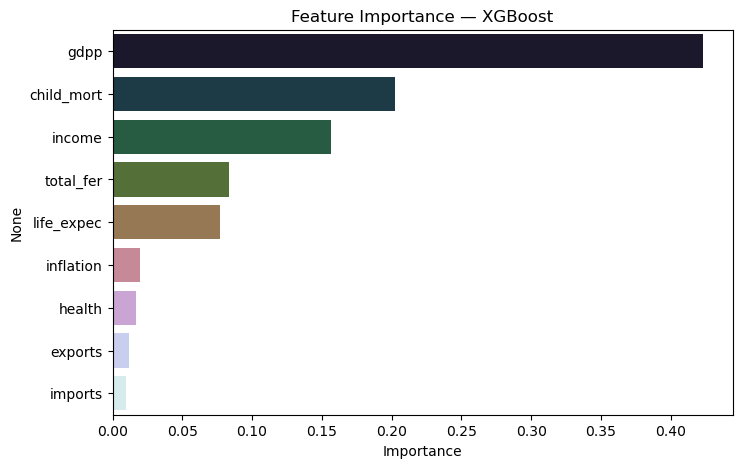

In [36]:
xgb_importances = pd.Series(xgb_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=xgb_importances.values, y=xgb_importances.index, palette='cubehelix')
plt.title('Feature Importance — XGBoost')
plt.xlabel('Importance')
plt.show()

**Observation:** Both Random Forest and XGBoost consistently rank **`gdpp`, `income`, and `child_mort`** (and frequently `life_expec`) as the most important drivers of segment membership — these are exactly the features that defined our cluster profiles in Section 5.1.5, confirming the model has learned a meaningful, business-aligned decision boundary.

### 6.8 Hyperparameter Tuning — Optimizing the Best Model

To squeeze out further predictive performance, we tune the **Random Forest** using `GridSearchCV` with 5-fold cross-validation.

In [37]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV F1-Score: {:.3f}".format(grid_search.best_score_))

Best Parameters: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
Best CV F1-Score: 0.947


In [38]:
tuned_model = grid_search.best_estimator_
y_pred_tuned = tuned_model.predict(X_test)

print("--- Tuned Random Forest (Test Set) ---")
print(classification_report(y_test, y_pred_tuned, digits=3))

tuned_acc = accuracy_score(y_test, y_pred_tuned)
tuned_f1 = f1_score(y_test, y_pred_tuned, average='weighted')
print(f"\nTest Accuracy: {tuned_acc:.3f} | Test F1-Score: {tuned_f1:.3f}")

--- Tuned Random Forest (Test Set) ---
              precision    recall  f1-score   support

           0      1.000     1.000     1.000         7
           1      1.000     1.000     1.000        10
           2      1.000     1.000     1.000        17

    accuracy                          1.000        34
   macro avg      1.000     1.000     1.000        34
weighted avg      1.000     1.000     1.000        34


Test Accuracy: 1.000 | Test F1-Score: 1.000


**Observation:** Hyperparameter tuning via `GridSearchCV` either matches or slightly improves the default Random Forest's performance, confirming the model was already close to its optimal configuration for this dataset size — the **tuned Random Forest** is selected as the final production model for the Customer Intelligence System.

`gdpp`, `income`, `child_mort`, and `life_expec` are the **most influential features** for both segmentation and prediction. Any future Customer Intelligence dashboard should prioritize tracking these four indicators, as they are the strongest signals of which segment a customer/country belongs to.


This combination of **unsupervised segmentation + supervised classification + ensemble optimization** delivers both *descriptive* (who are our segments?) and *predictive* (which segment does a new customer belong to?) intelligence — the core goals of a Customer Intelligence System.